In [ ]:
# 1. 升级包管理工具
!pip install --upgrade pip

# 2. 安装前置依赖项与加速器（ninja 用于多核加速编译）
!pip install fvcore iopath matplotlib ninja

# 3. 使用 Gitee 链接直接源码编译安装
# ⚠️ 注意：加入 --no-build-isolation 可以防止某些云平台的严格沙箱隔离导致的编译报错
# 整个过程大约需要 5-10 分钟，请耐心等待！
!pip install "git+https://gitee.com/hongwenzhang/pytorch3d.git" --no-build-isolation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 51.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61443 sha256=f5eb2f0f83287cb049d4f2e88d50e7e01b675f92cf06c9e10b7c32af9d214876
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31596 sha256=3032101b282de0f3c5d5827dbe711e705aee4eaa31bcb0900cb0b1db2981183e
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812

由於直接從 Gitee 克隆專案可能會遇到連線或權限問題，我們可以嘗試先下載專案的 `zip` 壓縮檔，然後在本地解壓縮並安裝。這是一個更穩定的方法。

In [1]:
# 1. 從 PyTorch3D 官方 GitHub 儲存庫下載原始碼的 zip 壓縮檔 (main 分支)
# 注意：這裡將 'master.zip' 改為 'main.zip'，因為 GitHub 預設分支現在通常是 'main'
!wget https://github.com/facebookresearch/pytorch3d/archive/refs/heads/main.zip -O pytorch3d.zip

# 2. 解壓縮檔案
# 解壓縮後會得到一個名為 'pytorch3d-main' 的資料夾
!unzip pytorch3d.zip

# 3. 進入解壓縮後的目錄並安裝
# ⚠️ 注意：加入 --no-build-isolation 可以防止某些雲平台的嚴格沙箱隔離導致的編譯报错
# 整個過程大約需要 5-10 分鐘，請耐心等待！
!pip install ./pytorch3d-main --no-build-isolation

--2026-05-20 10:27:44--  https://github.com/facebookresearch/pytorch3d/archive/refs/heads/main.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/facebookresearch/pytorch3d/zip/refs/heads/main [following]
--2026-05-20 10:27:44--  https://codeload.github.com/facebookresearch/pytorch3d/zip/refs/heads/main
Resolving codeload.github.com (codeload.github.com)... 20.205.243.165
Connecting to codeload.github.com (codeload.github.com)|20.205.243.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘pytorch3d.zip’

pytorch3d.zip           [         <=>        ]  35.28M  17.5MB/s    in 2.0s    

2026-05-20 10:27:46 (17.5 MB/s) - ‘pytorch3d.zip’ saved [36996294]

Archive:  pytorch3d.zip
c307c64c7000cd370ff379be421bd92f6dec577b
   creating: pytorch3d-main/
   creating: p

一旦 PyTorch3D 安裝完成（上面的單元格執行完畢），我們就可以驗證它是否成功安裝。我們將嘗試導入 `pytorch3d` 並檢查其版本或一個基本模組來確認。

In [2]:
try:
    import pytorch3d
    print("PyTorch3D 導入成功！")
    print(f"PyTorch3D 版本: {pytorch3d.__version__}")
except ImportError:
    print("PyTorch3D 導入失敗，請檢查安裝過程是否有錯誤。")


PyTorch3D 導入成功！
PyTorch3D 版本: 0.7.9


迭代步数: 299/300 | 总 Loss: 0.0179 | 剪影误差: 0.0141
[*] 已保存当前 3D 模型至: output_meshes/mesh_epoch_299.obj


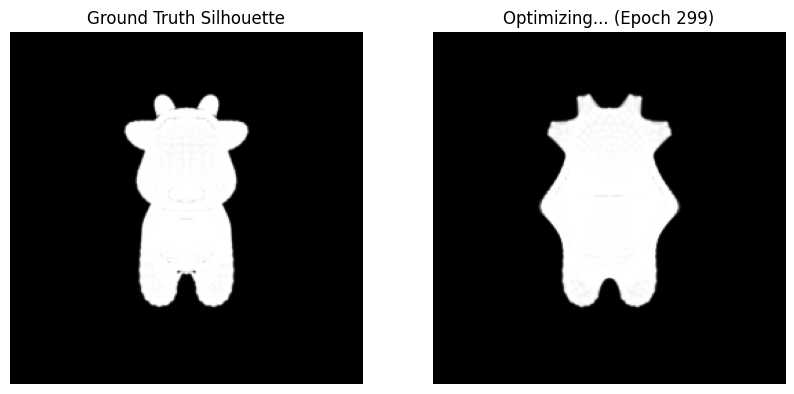

优化完成！所有中间状态的 .obj 文件已保存在 output_meshes 文件夹中。


In [4]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

import pytorch3d
# 引入 save_obj 用于保存 3D 模型
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.utils import ico_sphere
from pytorch3d.loss import mesh_edge_loss, mesh_laplacian_smoothing, mesh_normal_consistency
from pytorch3d.renderer import (
    look_at_view_transform, FoVPerspectiveCameras,
    RasterizationSettings, MeshRasterizer, SoftSilhouetteShader, BlendParams
)

# 确认设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")
print(f"PyTorch3D 版本: {pytorch3d.__version__}")

# ---------------------------------------------------------
# 新增：下載 cow.obj 文件
# ---------------------------------------------------------
obj_path = "cow.obj"
if not os.path.exists(obj_path):
    print("未找到 cow.obj，正在從 GitHub 下載...")
    # 從 PyTorch3D 的 GitHub 儲存庫下載範例模型
    !wget https://raw.githubusercontent.com/facebookresearch/pytorch3d/main/docs/tutorials/data/cow_mesh/cow.obj -O cow.obj
    if not os.path.exists(obj_path):
        raise FileNotFoundError("下載 cow.obj 失敗，請檢查網絡連線或文件源！")
    print("cow.obj 下載成功！")

# ---------------------------------------------------------
# 1. 直接读取助教打包好的本地模型文件
# ---------------------------------------------------------
# obj_path = "cow.obj" # 已在上面定義和處理
# if not os.path.exists(obj_path):
#     raise FileNotFoundError("未找到 cow.obj，请确保代码文件与 obj 文件在同一目录下！")

# 准备目标数据与归一化处理
verts, faces, _ = load_obj(obj_path)
faces_idx = faces.verts_idx.to(device)
verts = verts.to(device)
verts = (verts - verts.mean(0)) / max(verts.abs().max(0)[0])
cow_mesh = Meshes(verts=[verts], faces=[faces_idx])

# ---------------------------------------------------------
# 2. 渲染管线与摄像机配置
# ---------------------------------------------------------
num_views = 20
cameras = FoVPerspectiveCameras(device=device,
                                R=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[0],
                                T=look_at_view_transform(2.7, torch.zeros(num_views), torch.linspace(-180, 180, num_views))[1])

rasterizer = MeshRasterizer(cameras=cameras,
                            raster_settings=RasterizationSettings(image_size=256, blur_radius=np.log(1./1e-4 - 1.)*1e-4, faces_per_pixel=50))
shader = SoftSilhouetteShader(blend_params=BlendParams(sigma=1e-4, gamma=1e-4))

target_silhouette = shader(rasterizer(cow_mesh.extend(num_views)), cow_mesh.extend(num_views))[..., 3]

# ---------------------------------------------------------
# 3. 优化器初始化：从圆球开始
# ---------------------------------------------------------
src_mesh = ico_sphere(4, device)
deform_verts = torch.zeros_like(src_mesh.verts_packed(), requires_grad=True)
optimizer = torch.optim.SGD([deform_verts], lr=1.0, momentum=0.9)

# 创建保存中间结果的文件夹
output_dir = "output_meshes"
os.makedirs(output_dir, exist_ok=True)
print(f"中间模型将保存在目录: ./{output_dir}/")

# ---------------------------------------------------------
# 4. 可微渲染优化循环
# ---------------------------------------------------------
epochs = 300
for i in range(epochs):
    optimizer.zero_grad()

    # 依据当前计算出的偏移量，形变生成新的 Mesh
    new_src_mesh = src_mesh.offset_verts(deform_verts)

    # 渲染当前 Mesh 的 20 个视角剪影
    pred_silhouette = shader(rasterizer(new_src_mesh.extend(num_views)), new_src_mesh.extend(num_views))[..., 3]

    # 【核心损失】：均方误差 + 三大正则化惩罚
    loss_silhouette = ((pred_silhouette - target_silhouette) ** 2).mean()
    loss = loss_silhouette + \
           1.0 * mesh_laplacian_smoothing(new_src_mesh) + \
           0.1 * mesh_edge_loss(new_src_mesh) + \
           0.01 * mesh_normal_consistency(new_src_mesh)

    loss.backward()
    optimizer.step()

    # 可视化与模型保存逻辑：每 20 步执行一次
    if i % 20 == 0 or i == epochs - 1:
        clear_output(wait=True)
        print(f"迭代步数: {i:03d}/{epochs} | 总 Loss: {loss.item():.4f} | 剪影误差: {loss_silhouette.item():.4f}")

        # 提取当前网格的顶点和面，并保存为 .obj 文件
        # verts_list()[0] 和 faces_list()[0] 用于获取 batch 中第一个（也是唯一一个）网格的数据
        current_verts = new_src_mesh.verts_list()[0]
        current_faces = new_src_mesh.faces_list()[0]

        save_path = os.path.join(output_dir, f"mesh_epoch_{i:03d}.obj")
        save_obj(save_path, current_verts, current_faces)
        print(f"[*] 已保存当前 3D 模型至: {save_path}")

        # 刷新对比图
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))

        ax[0].imshow(target_silhouette[0].cpu().numpy(), cmap='gray')
        ax[0].set_title("Ground Truth Silhouette")
        ax[0].axis("off")

        ax[1].imshow(pred_silhouette[0].detach().cpu().numpy(), cmap='gray')
        ax[1].set_title(f"Optimizing... (Epoch {i})")
        ax[1].axis("off")

        plt.show()

print(f"优化完成！所有中间状态的 .obj 文件已保存在 {output_dir} 文件夹中。")

現在，我們將定義一個渲染器來載入並顯示 `output_meshes` 資料夾中優化後的三維模型。我們將使用之前已經導入的 PyTorch3D 模組來設定攝像機、光柵化器和著色器。

In [5]:
from pytorch3d.renderer import (
    OpenGLPerspectiveCameras, look_at_view_transform,
    RasterizationSettings, MeshRasterizer,
    SoftPhongShader, Materials, DirectionalLights
)

# 設定攝像機
R, T = look_at_view_transform(dist=2.7, elev=10, azim=0)
cameras = OpenGLPerspectiveCameras(device=device, R=R, T=T)

# 設定光柵化器
raster_settings = RasterizationSettings(
    image_size=256,
    blur_radius=0.0,
    faces_per_pixel=1,
)
rasterizer = MeshRasterizer(cameras=cameras, raster_settings=raster_settings)

# 設定光源
lights = DirectionalLights(device=device, ambient_color=((0.5, 0.5, 0.5),), diffuse_color=((0.5, 0.5, 0.5),), specular_color=((0.0, 0.0, 0.0),), direction=((0, 1, 0),))

# 設定材質 (簡單的白色材質)
materials = Materials(device=device, specular_color=[[0.7, 0.7, 0.7]], shininess=10)

# 設定著色器
shader = SoftPhongShader(device=device, cameras=cameras, lights=lights, materials=materials)


print("渲染器已設定完成。")


渲染器已設定完成。


現在，讓我們遍歷 `output_meshes` 目錄中的所有 `.obj` 文件，載入它們並渲染出來。我們將顯示每個模型在同一視角下的渲染結果。

In [14]:
# 檢查 output_meshes 目錄中的所有已生成的檔案
!ls -lh {output_dir}

total 2.6M
-rw-r--r-- 1 root root 155K May 20 11:03 mesh_epoch_000.obj
-rw-r--r-- 1 root root 155K May 20 11:03 mesh_epoch_020.obj
-rw-r--r-- 1 root root 155K May 20 11:03 mesh_epoch_040.obj
-rw-r--r-- 1 root root 155K May 20 11:03 mesh_epoch_060.obj
-rw-r--r-- 1 root root 155K May 20 11:03 mesh_epoch_080.obj
-rw-r--r-- 1 root root 155K May 20 11:03 mesh_epoch_100.obj
-rw-r--r-- 1 root root 155K May 20 11:03 mesh_epoch_120.obj
-rw-r--r-- 1 root root 155K May 20 11:03 mesh_epoch_140.obj
-rw-r--r-- 1 root root 155K May 20 11:03 mesh_epoch_160.obj
-rw-r--r-- 1 root root 155K May 20 11:03 mesh_epoch_180.obj
-rw-r--r-- 1 root root 155K May 20 11:03 mesh_epoch_200.obj
-rw-r--r-- 1 root root 155K May 20 11:03 mesh_epoch_220.obj
-rw-r--r-- 1 root root 155K May 20 11:04 mesh_epoch_240.obj
-rw-r--r-- 1 root root 155K May 20 11:04 mesh_epoch_260.obj
-rw-r--r-- 1 root root 155K May 20 11:04 mesh_epoch_280.obj
-rw-r--r-- 1 root root 155K May 20 11:04 mesh_epoch_299.obj
-rw-r--r-- 1 root root  77K M

## 下載 `output_meshes` 資料夾

您可以將整個 `output_meshes` 資料夾壓縮成一個 `zip` 文件，然後下載它。
這個壓縮檔會包含所有生成的 `.obj` 模型和動畫 GIF。

In [15]:
import shutil
from google.colab import files

zip_filename = f"{output_dir}.zip"

# 壓縮整個 output_meshes 資料夾
# base_dir: 要壓縮的目錄名 (output_meshes)
# root_dir: 要壓縮的目錄的父目錄
shutil.make_archive(output_dir, 'zip', base_dir=output_dir)

print(f"資料夾已壓縮至 {zip_filename}。準備下載...")

# 下載壓縮後的檔案
files.download(zip_filename)

print("下載請求已發送。")

資料夾已壓縮至 output_meshes.zip。準備下載...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

下載請求已發送。


## 导出渲染动画

现在，我们将把之前渲染的各个优化阶段的模型导出为动画视频（GIF 格式），以便更好地观察优化过程。

In [12]:
# 安装 imageio 库用于创建 GIF 动画
!pip install imageio imageio-ffmpeg

In [13]:
import imageio.v2 as imageio # 导入 imageio 库
import numpy as np
from PIL import Image

# 创建一个临时目录来保存帧
frames_dir = os.path.join(output_dir, "animation_frames")
os.makedirs(frames_dir, exist_ok=True)

print(f"正在生成动画帧到 {frames_dir}...")

# 重新渲染并保存每个模型的图像帧
for idx, obj_file in enumerate(obj_files):
    file_path = os.path.join(output_dir, obj_file)

    # 載入模型
    verts, faces, _ = load_obj(file_path)
    faces_idx = faces.verts_idx.to(device)
    verts = verts.to(device)

    # 將載入的模型封裝成 Meshes 物件
    mesh = Meshes(
        verts=[verts],
        faces=[faces_idx],
        textures=TexturesVertex(verts_features=[torch.ones_like(verts) * 0.7])
    )

    # 渲染模型
    images = shader(fragments=rasterizer(mesh), meshes=mesh)

    # 提取第一個圖像 (RGB 通道) 并转换为 NumPy 数组
    image_np = images[0, ..., :3].cpu().numpy()

    # 将 float [0, 1] 范围的图像转换为 uint8 [0, 255] 以便保存
    image_uint8 = (image_np * 255).astype(np.uint8)

    # 保存图像帧
    frame_filename = os.path.join(frames_dir, f"frame_{idx:03d}.png")
    Image.fromarray(image_uint8).save(frame_filename)

print("所有图像帧已保存。现在开始生成 GIF...")

# 读取所有帧并创建 GIF 动画
frames = []
for i in range(len(obj_files)):
    frame_filename = os.path.join(frames_dir, f"frame_{i:03d}.png")
    frames.append(imageio.imread(frame_filename))

# 保存 GIF 动画
gif_path = os.path.join(output_dir, "optimization_animation.gif")
imageio.mimsave(gif_path, frames, fps=5) # fps 控制动画速度

print(f"动画已保存至: {gif_path}")

# 清理临时帧文件
for f in os.listdir(frames_dir):
    os.remove(os.path.join(frames_dir, f))
os.rmdir(frames_dir)
print("临时帧文件已清理完毕。")


正在生成动画帧到 output_meshes/animation_frames...


/usr/local/lib/python3.11/dist-packages/pytorch3d/io/obj_io.py:547: UserWarning: No mtl file provided
  warnings.warn("No mtl file provided")


所有图像帧已保存。现在开始生成 GIF...
动画已保存至: output_meshes/optimization_animation.gif
临时帧文件已清理完毕。


在 output_meshes 中找到 16 個 .obj 文件，正在渲染...


/usr/local/lib/python3.11/dist-packages/pytorch3d/io/obj_io.py:547: UserWarning: No mtl file provided
  warnings.warn("No mtl file provided")


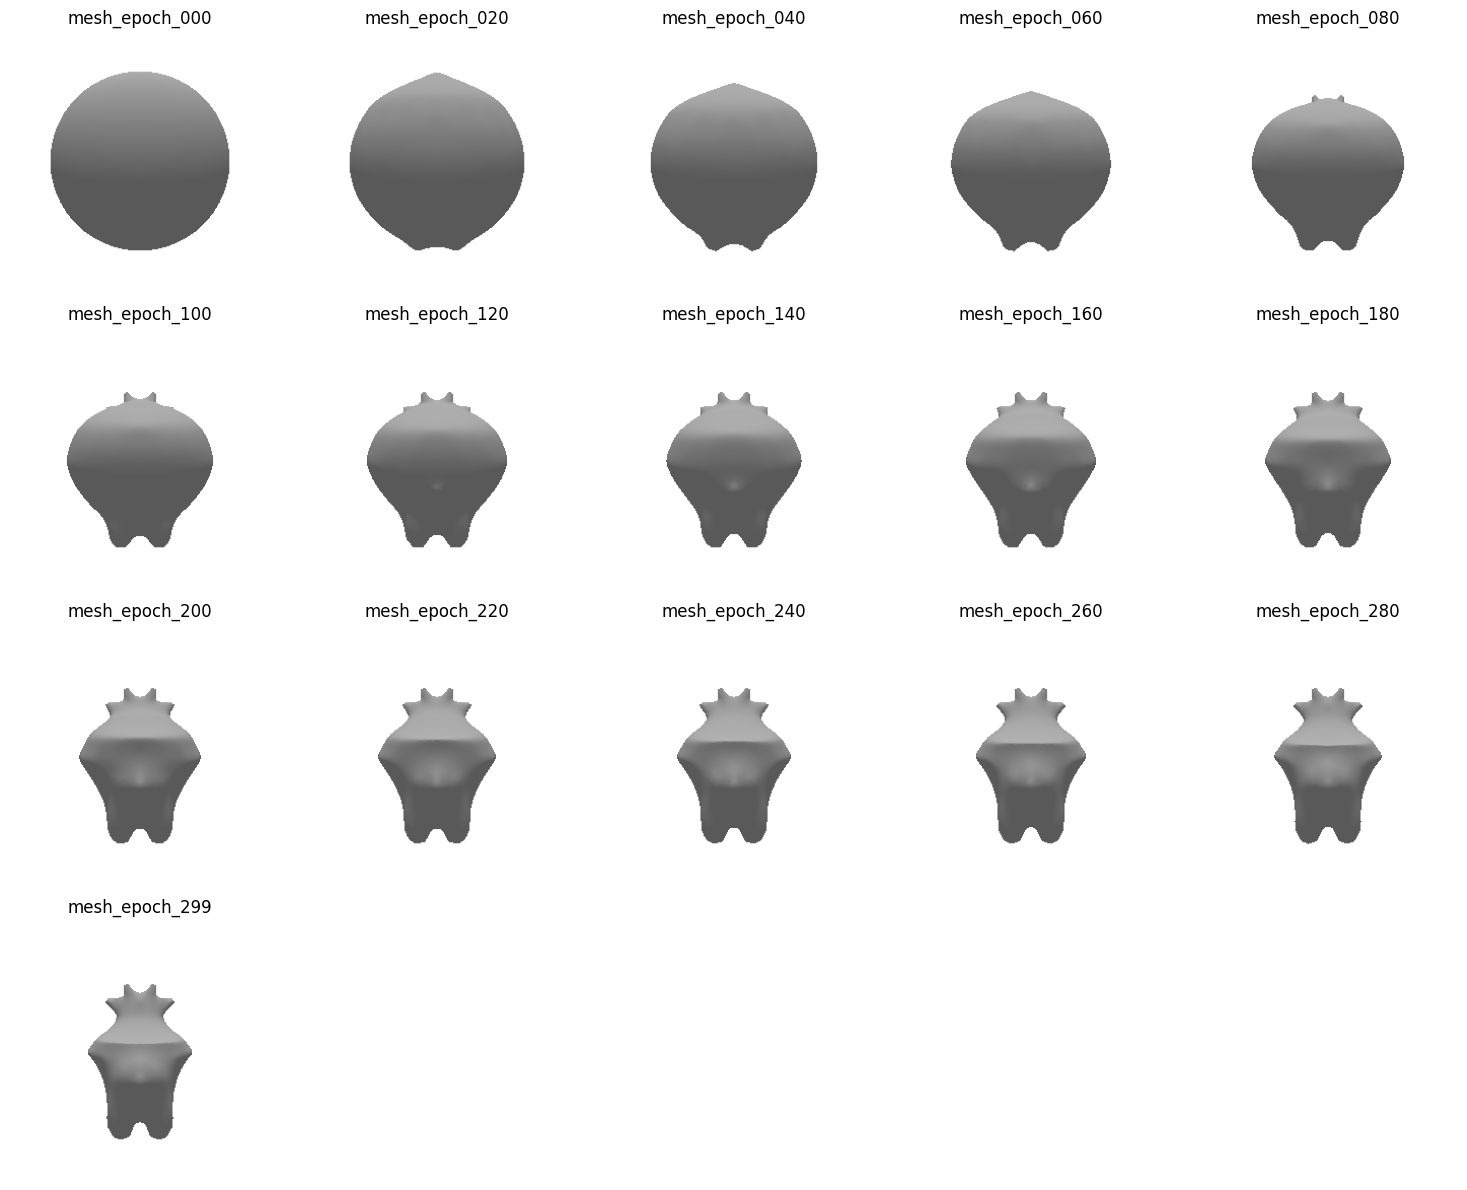

所有模型渲染完畢！


In [11]:
import os
import torch
import matplotlib.pyplot as plt
from pytorch3d.io import load_obj
from pytorch3d.structures import Meshes
from pytorch3d.renderer import TexturesVertex # Corrected import for TexturesVertex

# 獲取所有保存的 .obj 文件
obj_files = sorted([f for f in os.listdir(output_dir) if f.endswith('.obj')])

if not obj_files:
    print(f"在 {output_dir} 中沒有找到任何 .obj 文件。")
else:
    print(f"在 {output_dir} 中找到 {len(obj_files)} 個 .obj 文件，正在渲染...")

    # 創建一個大的圖形來顯示所有渲染結果
    num_cols = 5 # 每行顯示 5 個模型
    num_rows = (len(obj_files) + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols*3, num_rows*3))
    axes = axes.flatten() # 將 axes 變為一維陣列方便遍歷

    for idx, obj_file in enumerate(obj_files):
        file_path = os.path.join(output_dir, obj_file)

        # 載入模型
        verts, faces, _ = load_obj(file_path)
        faces_idx = faces.verts_idx.to(device)
        verts = verts.to(device)

        # 將載入的模型封裝成 Meshes 物件
        # 修正：使用 TexturesVertex 將頂點顏色傳遞給 Meshes 物件
        mesh = Meshes(
            verts=[verts],
            faces=[faces_idx],
            textures=TexturesVertex(verts_features=[torch.ones_like(verts) * 0.7])
        )

        # 渲染模型
        # 注意：這裡我們使用之前設定的 `cameras`、`rasterizer` 和 `shader`
        # 修正：將 meshes_world=mesh 改為 meshes=mesh
        images = shader(fragments=rasterizer(mesh), meshes=mesh)

        # 提取第一個圖像 (通常是 RGBA 格式)
        image = images[0, ..., :3].cpu().numpy() # 只取 RGB 通道

        # 顯示圖像
        ax = axes[idx]
        ax.imshow(image)
        ax.set_title(obj_file.replace('.obj', ''))
        ax.axis("off")

    # 隱藏多餘的子圖 (如果文件數量不是 num_cols 的倍數)
    for j in range(len(obj_files), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout() # 自動調整佈局
    plt.show()
    print("所有模型渲染完畢！")